# **03 · 뉴스 소비 건강지수(NCHI) — 단년 스냅샷에서 7개년 추세로**

### **"신뢰는 측정불변이 받쳐주니 연도를 비교하고, 다양성은 formative라 절대수준 대신 방향만 읽는다 — 두 축을 기하평균으로 묶어 7개년 NCHI 추세를 그린다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자** · 산출 = 연도별 신뢰·다양성·NCHI 추세 + 페르소나 구성비 추세

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **③ 모델링·지수화** · CRISP-DM **P4(Modeling)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 뉴스 **신뢰**는 2019~2025에 걸쳐 어떻게 움직였는가 — 측정불변(MGCFA)이 받쳐주므로 *연도 비교*가 정당한가?
> **Q2.** 뉴스 **다양성**(매체 폭)은 어느 방향으로 가는가 — formative 구성의 한계 안에서 *추세*는 무엇을 말하는가?
> **Q3.** 두 축을 묶은 **NCHI**(기하평균)의 7개년 궤적과 **페르소나 구성비** 변화는 무엇을 시사하는가?

→ 이 노트북은 새 수학을 만들지 않는다. `src/health_index_panel.py`(thin 어댑터, #156)가 `harmonize.py` 패널에 적용한 연도별 지수를 호출해 **추세로 시각화·해석**하는 P4 단계다.

## **목차**

| § | 내용 | 핵심 질문 | 비교 가능성 |
|:--:|------|-----------|:--:|
| 1 | 신뢰지수 추세 (+ DB①) | 연도별 신뢰 궤적 | ✅ 연도 비교 |
| 2 | 다양성지수 추세 fixed8·incl (+ DB②) | 매체 폭 방향 | ⚠️ 방향성만 |
| 3 | NCHI 추세 (기하평균) | 종합 건강 궤적 | ⚠️ 방향성 위주 |
| 4 | 페르소나 구성비 추세 | 4사분면 이동 | ⚠️ 방향성만 |
| 5 | 종합 · 한계(v1→v2) · 다음 | 결론 | — |

## **변경 이력 — v1(2025 단년) → v2(7개년 패널)**

| 항목 | **v1** (이전 노트북) | **v2** (현재, A트랙 ④) |
|------|----------------------|------------------------|
| 입력 | `news_health_features.load_2025()` — 2025 단년 6,000행 | `health_index_panel.load_panel()` — 7개년 통합 패널(90,996행) |
| 신뢰 | 코어 22문항 z평균(단년) | cred 핵심3{공정·전문·정확} pooled z평균 — **연도 비교**(MGCFA 측정불변) |
| 다양성 | Richness(0~12) 단년 | `richness_fixed8`(공통 8매체) **+ `richness_incl`(신설포함)** 2버전 추세 |
| 산출 | 단년 NCHI·연령대 프로파일·4사분면 | **연도별** 신뢰·다양성·NCHI **추세** + 페르소나 구성비 추세 |
| 가중 | `WT`(단년) | `wt_year_eq`(2022 표본지배 64.8% 보정) |

> ⚠️ **해석 규약**: 신뢰축(reflective)은 측정불변이 지지되어 *연도 절대수준 비교 가능*. 다양성·NCHI는 **formative** 구성 → *절대수준 비교 금지·방향성(추세)만* 해석(06 §결과 R4). 산출 수치는 KPF 원자료 재검증 **전 셀 일치**(kpf-revalidation, 2026-07-11 · 입증 노트북 `12`)로 인용 자격 확정 — 자격등급은 p6-pdf-structure §3.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

# 레포 루트 탐색 → src 경로 등록
ROOT = Path.cwd()
while not (ROOT / "src" / "health_index_panel.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz                 # 패널 스펙(SSOT): YEARS·credibility 핵심3
import news_health_features as nf      # 공통 수학(persona_quadrant·_scale_1_100)
import health_index_panel as hp        # thin 어댑터(#156): 연도별 지수 산출

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception:
            continue
    plt.rcParams["axes.unicode_minus"] = False   # 마이너스 깨짐 방지(ASCII -)
_kfont()

panel = hp.load_panel()
print(f"패널 로드: {len(panel):,}행 · 연도 {hz.YEARS}")
print(f"가중치 = wt_year_eq(2022 표본지배 보정) · 신뢰 핵심3 = {hz.CRED_FACTOR_CORE3}")
print("연도별 N:", panel["year"].value_counts().sort_index().to_dict())

패널 로드: 90,996행 · 연도 [2019, 2020, 2021, 2022, 2023, 2024, 2025]
가중치 = wt_year_eq(2022 표본지배 보정) · 신뢰 핵심3 = ['cred_fair', 'cred_professional', 'cred_accurate']
연도별 N: {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}


## 1. 신뢰지수 추세 — reflective, **연도 비교 가능**

신뢰지수 = credibility 핵심3{공정·전문·정확}의 7개년 pooled z평균 → [1,100] → 연도별 `wt_year_eq` 가중평균. 신뢰축은 **reflective** 구성이고, MGCFA(노트북 21·22)에서 측정불변(metric+)이 지지되어 **연도 간 절대수준 비교가 정당**하다.

In [2]:
trust = hp.trust_index_panel(panel)
print("[연도별 신뢰지수 — cred 핵심3 z평균 → [1,100], wt_year_eq 가중]")
print(trust.to_string(float_format=lambda x: f"{x:.1f}"))
peak = trust["trust_index"].idxmax(); low = trust["trust_index"].idxmin()
print(f"\n최고 {peak}년 {trust.loc[peak,'trust_index']:.1f} / 최저 {low}년 {trust.loc[low,'trust_index']:.1f} "
      f"(폭 {trust['trust_index'].max()-trust['trust_index'].min():.1f}p)")

[연도별 신뢰지수 — cred 핵심3 z평균 → [1,100], wt_year_eq 가중]
      trust_index  n_valid
2019         51.3     5040
2020         56.6     5010
2021         58.0     5010
2022         55.7    58936
2023         55.2     5000
2024         54.8     6000
2025         60.1     6000

최고 2025년 60.1 / 최저 2019년 51.3 (폭 8.8p)


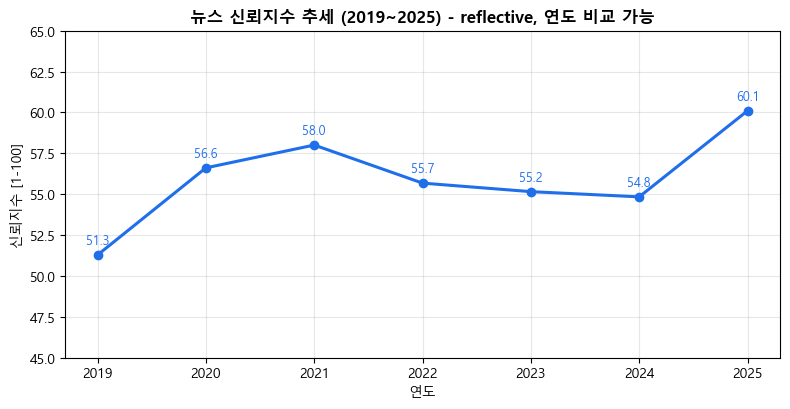

In [3]:
# [시각화] 신뢰지수 7개년 추세
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(trust.index, trust["trust_index"], marker="o", lw=2.2, color="#1f6feb")
for y, v in trust["trust_index"].items():
    ax.annotate(f"{v:.1f}", (y, v), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, color="#1f6feb")
ax.set_title("뉴스 신뢰지수 추세 (2019~2025) - reflective, 연도 비교 가능", fontsize=12, weight="bold")
ax.set_xlabel("연도"); ax.set_ylabel("신뢰지수 [1-100]")
ax.set_ylim(45, 65); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

> #### 🟦 Decision Box ① — 왜 신뢰만 '연도 비교'를 허용하나?
>
> **결정**: 신뢰지수는 연도 간 **절대수준 비교**를 허용하되, 다양성·NCHI는 방향성만 본다.
>
> **근거**: 신뢰는 cred 핵심3 지표가 공통 잠재요인(신뢰성)을 *반영(reflective)*하는 구조다. MGCFA(노트북 21·22)에서 형상·메트릭 불변이 지지되어, 연도가 달라도 **같은 자(척도)로 잰 값**으로 볼 수 있다(mgcfa-invariance-results.md). 따라서 "2021이 2019보다 높다"는 진술이 측정학적으로 방어된다.
>
> **대안 기각**: 신뢰도 방향성만 보기 → 측정불변이 입증된 축의 정보를 버리는 과보수. 채택하지 않음.

#### **[발견 ①] 신뢰는 2019 저점 → 2021 회복 → 2025 최고로, 완만한 우상향**

신뢰지수는 2019년 51.3으로 가장 낮고, 2020~2021년 코로나기 정보수요 속 56~58로 올라섰다가 2022~2024년 55 안팎에서 횡보, 2025년 60.1로 최고치를 찍는다. 측정불변이 받쳐주므로 이 **연도 비교는 유효**하며, 전체적으로 신뢰는 붕괴가 아니라 **완만한 회복·상승** 국면으로 읽힌다.

→ **① 신뢰지수 추세 — 완료(연도 비교 정당, 우상향 확인). 다음은 방향성만 허용되는 다양성.**

## 2. 다양성지수 추세 — formative, **방향성만** (fixed8 주지표 + incl 보조)

다양성지수 = 매체 이용 폭(Richness) → [1,100]. 두 버전을 병기한다.
- **fixed8**: 7개년 공통 8매체 고정풀(0~8) 기반 → **종단 비교 주지표**(매체 구성 고정 → 추세 왜곡 최소).
- **incl**: 신설 디지털매체(숏폼·OTT·AI 등) 포함(0~11). 부재 연도는 fixed8과 동일 → fixed8 대비 **'신설 기여'**를 가시화하는 보조.

In [4]:
div = hp.diversity_index_panel(panel)
print("[연도별 다양성지수 — fixed8(주) / incl(신설포함, 보조), wt_year_eq 가중]")
print(div.to_string(float_format=lambda x: f"{x:.1f}"))

# ⚠️ 두 지수는 각각 독립 min-max 정규화 → 레벨 비교 불가(incl은 더 넓은 풀로 나눠 낮게 보임).
#    '신설 기여'는 정규화 이전 RAW richness 수준에서 봐야 정직하다.
raw_fixed = hp._by_year_wmean(panel, pd.to_numeric(panel["richness_fixed8"], errors="coerce"), "wt_year_eq")
raw_incl  = hp._by_year_wmean(panel, pd.to_numeric(panel["richness_incl"],   errors="coerce"), "wt_year_eq")
rawcmp = pd.DataFrame({"raw_fixed8": raw_fixed, "raw_incl": raw_incl})
rawcmp["신설기여(incl-fixed8)"] = rawcmp["raw_incl"] - rawcmp["raw_fixed8"]
print("\n[RAW Richness 가중평균 — 신설 기여(정규화 전, 매체수 단위)]")
print(rawcmp.to_string(float_format=lambda x: f"{x:.2f}"))
print("⚠️ formative 구성 → 지수 절대수준 비교 금지. 아래는 '방향(기울기)'만 해석한다.")

[연도별 다양성지수 — fixed8(주) / incl(신설포함, 보조), wt_year_eq 가중]
      diversity_index_fixed8  diversity_index_incl  n_valid
2019                    28.5                  21.0     5040
2020                    29.8                  22.0     5010
2021                    30.3                  22.3     5010
2022                    26.8                  19.8    58936
2023                    27.7                  22.0     5000
2024                    26.8                  21.1     6000
2025                    28.5                  23.7     6000

[RAW Richness 가중평균 — 신설 기여(정규화 전, 매체수 단위)]
      raw_fixed8  raw_incl  신설기여(incl-fixed8)
2019        2.22      2.22               0.00
2020        2.33      2.33               0.00
2021        2.36      2.36               0.00
2022        2.09      2.09               0.00
2023        2.15      2.33               0.18
2024        2.08      2.23               0.15
2025        2.22      2.52               0.30
⚠️ formative 구성 → 지수 절대수준 비교 금지. 아래는 '방향(기울기)'만 해석한다

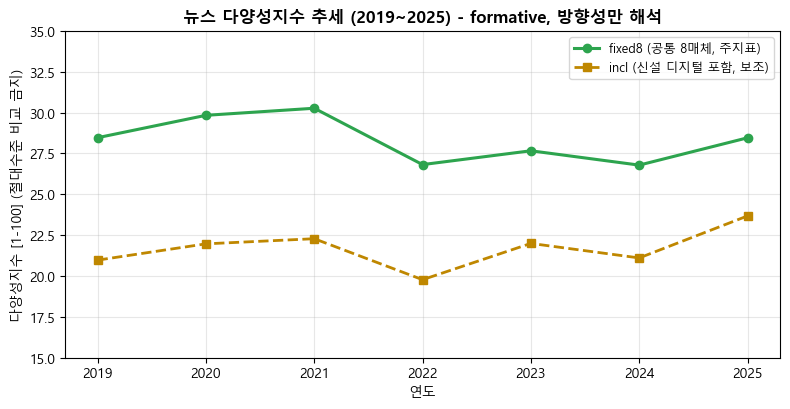

In [5]:
# [시각화] 다양성 fixed8 vs incl 추세 — 방향성 비교
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(div.index, div["diversity_index_fixed8"], marker="o", lw=2.2,
        color="#2da44e", label="fixed8 (공통 8매체, 주지표)")
ax.plot(div.index, div["diversity_index_incl"], marker="s", lw=2.0, ls="--",
        color="#bf8700", label="incl (신설 디지털 포함, 보조)")
ax.set_title("뉴스 다양성지수 추세 (2019~2025) - formative, 방향성만 해석", fontsize=12, weight="bold")
ax.set_xlabel("연도"); ax.set_ylabel("다양성지수 [1-100] (절대수준 비교 금지)")
ax.set_ylim(15, 35); ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> #### 🟩 Decision Box ② — formative 축은 왜 '방향만' 읽나?
>
> **결정**: 다양성은 **연도 절대수준 비교를 금지**하고, fixed8의 **기울기(방향)**만 해석한다. incl은 신설 기여 가시화 용도로만 병기.
>
> **근거**: Richness는 "어떤 매체를 쓰는가"가 지수를 *구성(formative)*한다 — 매체 목록이 바뀌면 지수의 의미가 바뀐다. 신설 매체(숏폼·OTT·AI)는 등장 연도가 제각각이라, 전체 풀로 비교하면 "다양성 증가"가 매체 *추가*인지 행동 *변화*인지 구분이 안 된다. 그래서 **구성을 고정한 fixed8**을 주지표로 삼아 방향만 본다(06 §결과 R4).
>
> **대안 기각**: incl을 주지표로 → 신설 매체 도입 시점 효과가 추세에 혼입되어 인과 해석 오염. fixed8 우선.

#### **[발견 ②] fixed8 다양성은 거의 평탄, 최근 증가분은 RAW 기준 '신설 매체 기여'에서 온다**

fixed8 다양성지수는 7개년 내내 27~30의 좁은 띠에서 움직여 **방향상 큰 변화가 없다**(공통 매체 기준 폭은 정체). '신설 기여'는 지수가 아니라 **정규화 이전 RAW Richness**(매체수)에서 읽어야 정직한데 — incl·fixed8 두 지수는 *각각 독립 min-max 정규화*되어 풀이 넓은 incl이 오히려 낮게 보이기 때문이다(레벨 비교 금지). RAW 기준 신설 기여(incl - fixed8)는 2022년까지 0이다가 **2023년 +0.18 → 2024 +0.15 → 2025 +0.30**으로 확대된다. 즉 최근의 '다양성 증가'처럼 보이는 부분은 기존 매체 확장이 아니라 **숏폼·OTT·AI 등 신설 채널 유입**에서 온다. formative 한계상 절대수준은 비교하지 않고 이 **방향성**만 취한다.

→ **② 다양성지수 추세 — 완료(fixed8 평탄·RAW 신설 기여 분리). 다음은 두 축을 묶은 NCHI.**

## 3. NCHI 추세 — 기하평균 √(신뢰 × 다양성)

NCHI = 연도별 √(신뢰 × 다양성) 기하평균(`news_health_features.nchi` 재사용). 기하평균은 한 축이 낮으면 종합점수를 자동 페널티(저보완성). 다양성 버전에 따라 fixed8(주)·incl(보조) 두 궤적을 병기한다.

In [6]:
nchi_fixed = hp.nchi_by_year(panel, diversity_version="fixed8")
nchi_incl  = hp.nchi_by_year(panel, diversity_version="incl")
print("[NCHI = sqrt(신뢰 x 다양성) — 다양성 fixed8(주지표)]")
print(nchi_fixed.to_string(float_format=lambda x: f"{x:.1f}"))
print("\n[NCHI — 다양성 incl(신설포함, 보조)]")
print(nchi_incl.to_string(float_format=lambda x: f"{x:.1f}"))

[NCHI = sqrt(신뢰 x 다양성) — 다양성 fixed8(주지표)]
      trust_index  diversity_index  nchi
2019         51.3             28.5  38.2
2020         56.6             29.8  41.1
2021         58.0             30.3  41.9
2022         55.7             26.8  38.6
2023         55.2             27.7  39.1
2024         54.8             26.8  38.3
2025         60.1             28.5  41.4

[NCHI — 다양성 incl(신설포함, 보조)]
      trust_index  diversity_index  nchi
2019         51.3             21.0  32.8
2020         56.6             22.0  35.3
2021         58.0             22.3  36.0
2022         55.7             19.8  33.2
2023         55.2             22.0  34.8
2024         54.8             21.1  34.0
2025         60.1             23.7  37.7


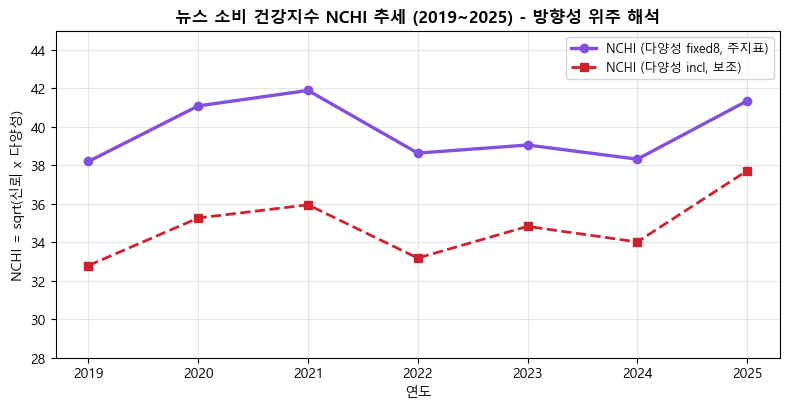

In [7]:
# [시각화] NCHI 추세 — fixed8 vs incl
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(nchi_fixed.index, nchi_fixed["nchi"], marker="o", lw=2.4,
        color="#8250df", label="NCHI (다양성 fixed8, 주지표)")
ax.plot(nchi_incl.index, nchi_incl["nchi"], marker="s", lw=2.0, ls="--",
        color="#cf222e", label="NCHI (다양성 incl, 보조)")
ax.set_title("뉴스 소비 건강지수 NCHI 추세 (2019~2025) - 방향성 위주 해석", fontsize=12, weight="bold")
ax.set_xlabel("연도"); ax.set_ylabel("NCHI = sqrt(신뢰 x 다양성)")
ax.set_ylim(28, 45); ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### **[발견 ③] NCHI는 신뢰가 끌고 다양성이 누른다 — 2021·2025 정점, 다양성이 천장 역할**

NCHI(fixed8)는 38~42의 좁은 범위에서 2020~2021년과 2025년에 정점을 보인다. 신뢰가 우상향(51→60)하는데도 NCHI 상승폭이 작은 이유는 **기하평균 구조상 낮은 다양성(27~30)이 종합점수를 끌어내리기 때문**이다 — 즉 한국 뉴스 소비 건강의 **병목은 신뢰가 아니라 다양성**이다. incl 궤적이 fixed8보다 낮은 것은 분모(매체 풀)가 커진 정의 차이이며, 절대 비교가 아니라 **두 정의의 방향이 함께 움직이는지**(강건성)를 보는 용도다.

→ **③ NCHI 추세 — 완료(다양성 병목 확인). 다음은 사람을 4사분면으로 나눈 페르소나 구성비.**

## 4. 페르소나 구성비 추세 — 신뢰 × 다양성 4사분면

응답자를 신뢰·다양성 두 축의 **pooled 중앙값**(연도 고정 임계값 → 구성비의 *방향* 비교 가능)으로 4사분면에 배치한다: 🟢건강한 소비자(고신뢰·고다양) / 🟡신뢰편향형(고신뢰·저다양) / 🟠비판적 탐색형(저신뢰·고다양) / 🔴이중취약형(저신뢰·저다양). 다양성은 fixed8 기준.

In [8]:
# 응답자 단위 점수 → pooled 임계값 고정 → 연도별 가중 구성비
T_resp = hp._trust_score_respondent(panel)                                   # pooled [1,100]
D_resp = nf._scale_1_100(pd.to_numeric(panel["richness_fixed8"], errors="coerce"))
persona = nf.persona_quadrant(T_resp, D_resp)                               # pooled 중앙값 고정

pdf = pd.DataFrame({"year": panel["year"].to_numpy(),
                    "persona": persona.to_numpy(),
                    "w": panel["wt_year_eq"].to_numpy()}).dropna(subset=["persona"])

order = ["건강한 소비자", "비판적 탐색형", "신뢰편향형", "이중취약형"]
share = (pdf.groupby(["year", "persona"])["w"].sum().unstack(fill_value=0))
share = (share.div(share.sum(axis=1), axis=0) * 100)[order].round(1)
print("[연도별 페르소나 가중 구성비 % — pooled 중앙값 임계값 고정]")
print(share.to_string())

[연도별 페르소나 가중 구성비 % — pooled 중앙값 임계값 고정]
persona  건강한 소비자  비판적 탐색형  신뢰편향형  이중취약형
year                                   
2019        29.8     43.8   12.4   14.0
2020        43.0     35.2   12.1    9.7
2021        46.5     31.0   13.7    8.8
2022        33.8     33.8   16.2   16.2
2023        34.8     32.0   16.0   17.2
2024        31.1     31.5   17.4   20.0
2025        42.2     25.6   20.4   11.9


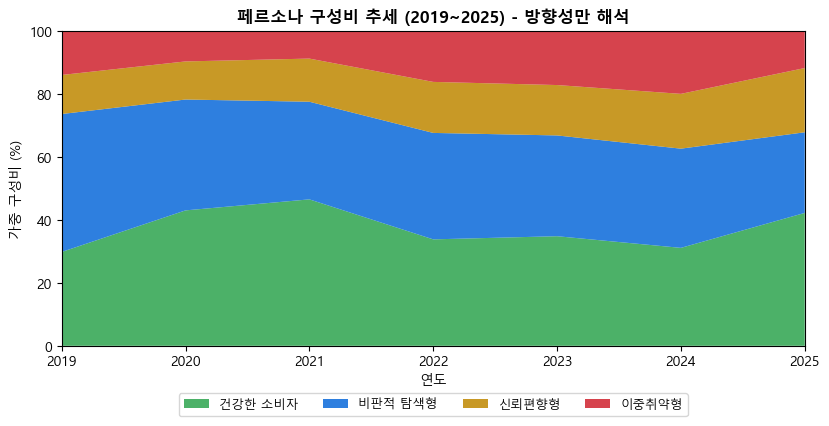

In [9]:
# [시각화] 페르소나 구성비 추세 — 누적 영역
colors = {"건강한 소비자": "#2da44e", "비판적 탐색형": "#0969da",
          "신뢰편향형": "#bf8700", "이중취약형": "#cf222e"}
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.stackplot(share.index, [share[c] for c in order],
             labels=order, colors=[colors[c] for c in order], alpha=0.85)
ax.set_title("페르소나 구성비 추세 (2019~2025) - 방향성만 해석", fontsize=12, weight="bold")
ax.set_xlabel("연도"); ax.set_ylabel("가중 구성비 (%)")
ax.set_ylim(0, 100); ax.margins(x=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

#### **[발견 ④] 신뢰 우상향은 분포에도 보이지만, 늘어난 고신뢰층이 '신뢰편향형'으로 샌다**

페르소나 임계값을 7개년 공통(pooled 중앙값)으로 고정해 구성비의 *방향*을 보면, **고신뢰 두 집단(🟢건강한 소비자 + 🟡신뢰편향형)의 합은 2019년 42% → 2025년 63%로 뚜렷이 증가**한다(§1 신뢰 우상향과 정합). 동시에 저신뢰·고다양의 🟠비판적 탐색형은 43.8% → 25.6%로 크게 줄었다. 그런데 늘어난 신뢰가 전부 '건강한 소비자'로 가지 못하고 **🟡신뢰편향형(고신뢰·저다양)이 12.4% → 20.4%로 꾸준히 누적**된다 — 다양성이 따라오지 못해 신뢰 상승분의 일부가 '편향형'으로 새는 것이다. §3의 **다양성 병목**이 개인 분포 수준에서도 재확인된다. 임계값을 고정했으므로 절대 비중보다 이 **방향성**을 취하며, **다양성 확장이 건강 개선의 지렛대**라는 함의는 일관된다.

→ **④ 페르소나 구성비 추세 — 완료(신뢰 상승의 '편향형 누수' 확인).**

## 5. 종합 · 한계(v1 → v2) · 다음

### 종합
- **신뢰(연도 비교 가능)**: 2019 저점 → 2021·2025 정점으로 완만한 우상향. 측정불변이 받쳐주는 유효한 비교.
- **다양성(방향성만)**: fixed8 기준 평탄, 최근 증가분은 대부분 신설 매체(숏폼·OTT·AI) 기여.
- **NCHI(방향성 위주)**: 신뢰가 끌어도 **낮은 다양성이 천장** → 한국 뉴스 소비 건강의 병목은 다양성.
- **페르소나**: 고신뢰층 비중 증가(42%→63%)하나 다양성 정체로 '신뢰편향형'이 누적(12%→20%) → 다양성 병목의 분포적 재확인.

### 한계 (v1 → v2 로드맵)
| 축 | v2 처리 | 한계 | v3 보완 방향 |
|----|--------|------|-------------|
| 신뢰 | reflective·측정불변 → 연도 비교 | 단조(역U 미반영: 맹신·냉소 모두 불건강) | 회의·리터러시 교차지표로 역U 보정 |
| 다양성 | formative → 방향성만·fixed8 주지표 | 절대수준·연도 비교 불가, 신설 매체 시점 효과 | scalar 불변 미검정 → 잠재평균 비교는 보류 |
| NCHI | 기하평균(저보완성) | 다양성 한계를 상속 → 절대수준 신중 | 다양성 측정 정교화 후 재산출 |

> ⚠️ 다양성·NCHI 절대수준은 **formative 한계** → 종단 해석은 방향성 위주(06 §결과 R4). 신뢰만 연도 비교 가능.
> 산출 수치는 KPF 원자료 재검증 **전 셀 일치**([kpf-revalidation](../docs/design/kpf-revalidation.md), 2026-07-11 · 입증 노트북 `12`)와 측정동등 검정(`21`~`23`) 통과로 인용 자격이 확정됐다 — 자격등급은 [p6-pdf-structure §3](../docs/report/p6-pdf-structure.md).

### 다음
1. **04-personas-kmeans**: 4사분면(규칙 기반)을 K-means로 데이터 주도 페르소나로 정교화 — 연도별 군집 이동.
2. **23 (예정)**: 다양성 scalar 불변 검정 → 통과 시 잠재평균(연도) 비교로 격상.
3. **웹 데모**: 연도 선택 → 신뢰·다양성·NCHI 추세 + 자가진단 페르소나 입력.

---
> **재현**: `python src/harmonize.py`(패널 재생성) → `python src/health_index_panel.py`(self-validation). 본 노트북은 어댑터 산출을 추세로 시각화·해석할 뿐 수학은 SSOT에 있다.